# 7. Varlık Bazlı Duygu Analizi (Aspect-Based Sentiment Analysis)

Bu bölümde önceden eğittiğimiz modeli kullanarak yorumları **Tat, Kalite, Fiyat, Ambalaj, Doku** gibi ürün özelliklerine göre parçalayıp duygu analizi yapıyoruz.

Dışarıdan hazır model (BERT vb.) kullanılmamaktadır; tamamen sıfırdan eğittiğimiz modeller ile çıkarım yapılır.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import joblib
import nltk
import scipy.sparse
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

## 7.1 Verilerin ve Modellerin Yüklenmesi

In [2]:
print('Modeller yükleniyor...')
tfidf_vectorizer = joblib.load('models/tfidf_vectorizer.pkl')
scaler_obj = joblib.load('models/scaler.pkl')
lr_model = joblib.load('models/lr_model.pkl')
print('Modeller yüklendi!')

print('\nVeri yükleniyor (10.000 rastgele satır)...')
df = pd.read_csv('data/reviews_preprocessed.csv').dropna(subset=['cleaned_text'])
df = df.sample(n=min(10000, len(df)), random_state=42).reset_index(drop=True)
print(f'Örnek veri boyutu: {df.shape}')

Modeller yükleniyor...


Modeller yüklendi!

Veri yükleniyor (10.000 rastgele satır)...


Örnek veri boyutu: (10000, 19)


## 7.2 Aspect (Varlık) Sözlüğü
Amazon gıda ürünleri için 5 temel varlık kategorisi tanımlıyoruz.

In [3]:
aspect_keywords = {
    'Tat/Lezzet': ['taste','flavor','delicious','bland','spicy','sweet','sour',
                   'bitter','yummy','savory','tasteless','flavorful','tasty'],
    'Kalite':     ['quality','fresh','stale','expire','organic','natural',
                   'artificial','processed','ingredient','genuine','pure'],
    'Fiyat/Değer':['price','expensive','cheap','worth','value','cost',
                   'money','affordable','overpriced','bargain','deal'],
    'Ambalaj':    ['package','packaging','box','bag','seal','shipping',
                   'delivery','arrived','damaged','broken','wrapped','container'],
    'Doku/Kıvam': ['texture','crunchy','soft','hard','chewy','smooth',
                   'creamy','dry','moist','crispy','thick','thin']
}

def get_aspects(sentence):
    s = sentence.lower()
    return [asp for asp, kws in aspect_keywords.items()
            if any(kw in s for kw in kws)]

## 7.3 Cümlelere Bölme ve Çıkarım

In [4]:
numeric_cols = ['review_length','word_count','exclamation_count','question_count',
                'avg_word_length','uppercase_ratio','sentiment_polarity',
                'sentiment_subjectivity']
X_num_scaled = scaler_obj.transform(df[numeric_cols])

aspect_results = []
print('Cümleler analiz ediliyor...')
for idx, row in df.iterrows():
    sentences = sent_tokenize(str(row['cleaned_text']))
    for sentence in sentences:
        aspects = get_aspects(sentence)
        if aspects:
            tfidf_m = tfidf_vectorizer.transform([sentence])
            num_m = X_num_scaled[idx].reshape(1, -1)
            combined = scipy.sparse.hstack([tfidf_m, scipy.sparse.csr_matrix(num_m)])
            pred = lr_model.predict(combined)[0]
            label_map = {0: 'Negatif', 1: 'Nötr', 2: 'Pozitif'}
            for asp in aspects:
                aspect_results.append({
                    'review_id': idx,
                    'aspect': asp,
                    'sentence': sentence,
                    'sentiment': label_map[pred]
                })

df_asp = pd.DataFrame(aspect_results)
print(f'Toplam {len(df_asp)} adet Varlık-Cümle eşleşmesi bulundu.')
df_asp.head(10)

Cümleler analiz ediliyor...


Toplam 18694 adet Varlık-Cümle eşleşmesi bulundu.


,review_id,aspect,sentence,sentiment
0,0,Tat/Lezzet,best price anywhere unless buying pound bag pa...,Pozitif
1,0,Kalite,best price anywhere unless buying pound bag pa...,Pozitif
2,0,Fiyat/Değer,best price anywhere unless buying pound bag pa...,Pozitif
3,0,Ambalaj,best price anywhere unless buying pound bag pa...,Pozitif
4,1,Kalite,experience expired via coffee occasionally oft...,Negatif
5,1,Ambalaj,experience expired via coffee occasionally oft...,Negatif
6,2,Tat/Lezzet,although tea expert drink tea daily tea bag te...,Negatif
7,2,Fiyat/Değer,although tea expert drink tea daily tea bag te...,Negatif
8,2,Ambalaj,although tea expert drink tea daily tea bag te...,Negatif
9,3,Ambalaj,purchased product wesaveyou storefront via ama...,Negatif


## 7.4 Sonuçların Görselleştirilmesi

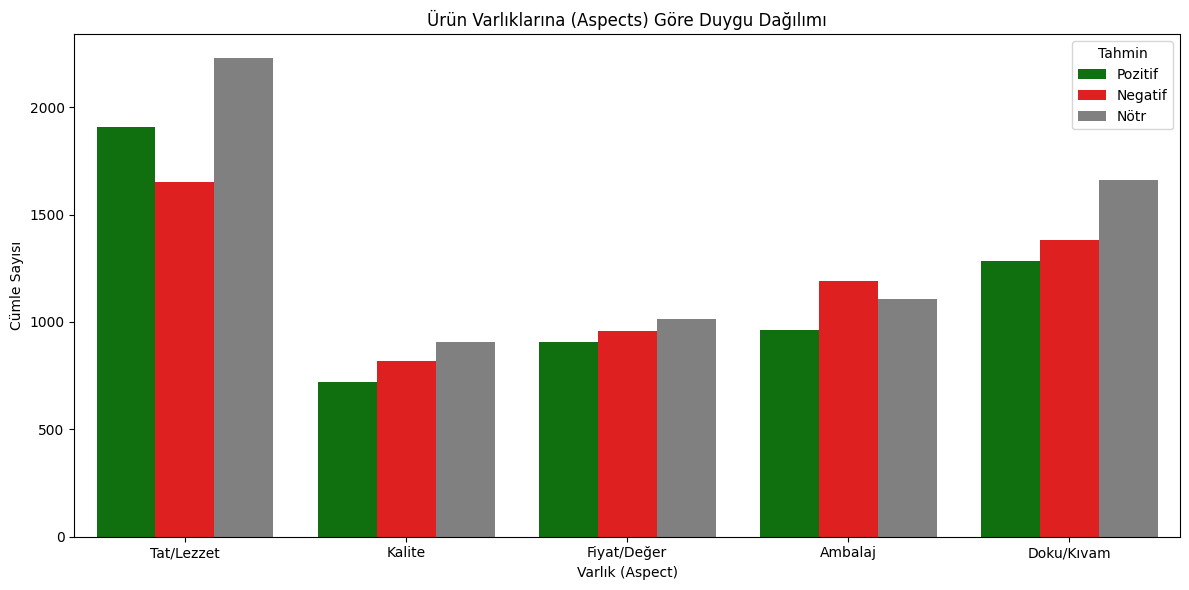

In [5]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_asp, x='aspect', hue='sentiment',
              palette={'Negatif':'red', 'Nötr':'gray', 'Pozitif':'green'})
plt.title('Ürün Varlıklarına (Aspects) Göre Duygu Dağılımı')
plt.xlabel('Varlık (Aspect)')
plt.ylabel('Cümle Sayısı')
plt.legend(title='Tahmin')
plt.tight_layout()
import os
os.makedirs('results', exist_ok=True)
plt.savefig('results/aspect_based_sentiment.png')
plt.show()

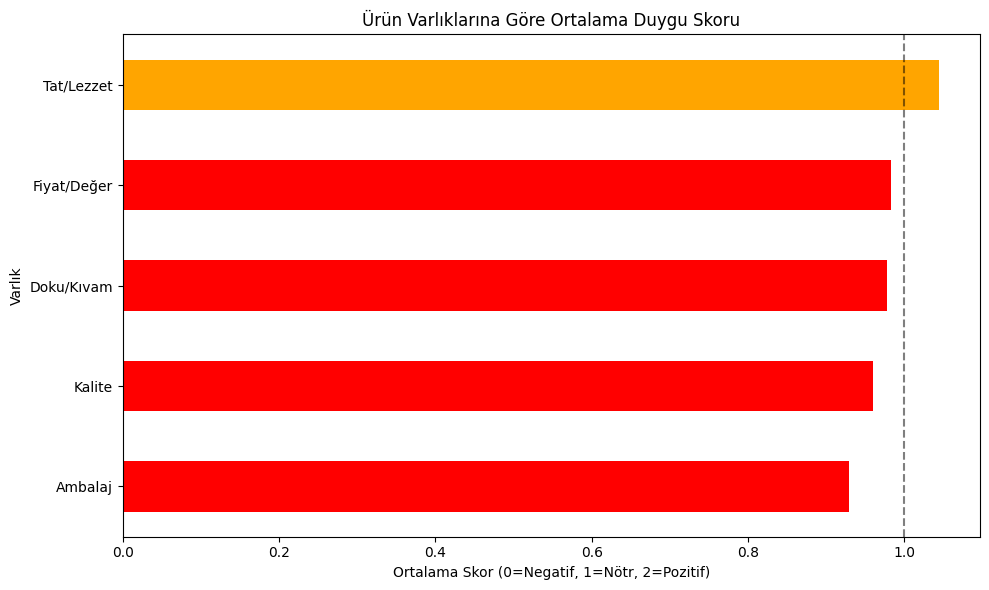


Varlık Bazlı Duygu Özeti:


sentiment,Negatif,Nötr,Pozitif
aspect,,,
Ambalaj,1191,1106,962
Doku/Kıvam,1381,1661,1285
Fiyat/Değer,958,1014,908
Kalite,816,908,719
Tat/Lezzet,1650,2227,1908


In [6]:
# Aspect bazında ortalama skor
score_map = {'Negatif': 0, 'Nötr': 1, 'Pozitif': 2}
df_asp['score'] = df_asp['sentiment'].map(score_map)

aspect_avg = df_asp.groupby('aspect')['score'].mean().sort_values()

plt.figure(figsize=(10, 6))
colors = ['red' if v < 1 else 'orange' if v < 1.5 else 'green' for v in aspect_avg.values]
aspect_avg.plot(kind='barh', color=colors)
plt.title('Ürün Varlıklarına Göre Ortalama Duygu Skoru')
plt.xlabel('Ortalama Skor (0=Negatif, 1=Nötr, 2=Pozitif)')
plt.ylabel('Varlık')
plt.axvline(x=1.0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('results/aspect_avg_score.png')
plt.show()

print('\nVarlık Bazlı Duygu Özeti:')
summary = df_asp.groupby(['aspect','sentiment']).size().unstack(fill_value=0)
display(summary)